In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import numpy as np
import pandas as pd
from collections import defaultdict
import ozy
import matplotlib.pyplot as plt


   ___                                           _  _             
  /___\ ____ _   _  _ __ ___    __ _  _ __    __| |(_)  __ _  ___ 
 //  //|_  /| | | || '_ ` _ \  / _` || '_ \  / _` || | / _` |/ __|
/ \_//  / / | |_| || | | | | || (_| || | | || (_| || || (_| |\__ \
\___/  /___| \__, ||_| |_| |_| \__,_||_| |_| \__,_||_| \__,_||___/
             |___/                                                

   (C) 2021 F. Rodriguez Montero
   Version 0.2.dev1



In [2]:
directory = '/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/'
ozy_files = []
for filename in glob.glob(os.path.join(directory, '*.hdf5')):
    ozy_files.append(filename)

ozy_file = ozy_files[0]
print(ozy_file)
sim = ozy.load(ozy_file)


/mnt/extraspace/currodri/newhorizon_rar/00925_100PerCentPurity/ozy_00925.hdf5


In [3]:
halos = sim.halos
galaxies = sim.galaxies

print(len(halos))
print(len(galaxies))

halo_ids = [halo.ID for halo in halos]

data = defaultdict(list)

#Loop over length of galaxies as its the shorter list
for i in range(len(galaxies)):

    ID_gal = galaxies[i].ID
    ID_host = galaxies[i].halo.ID

    halo_index = halo_ids.index(ID_host)

    
    data['Number'].append(int(ID_gal))
    data['Galaxy Mass (Msun)'].append(float(galaxies[i].virial_quantities['mass'].to('Msun').value))
    data['Galaxy Radius (Kpc)'].append(float(galaxies[i].virial_quantities['radius'].to('kpc').value))
    data['Galaxy Temperature (K)'].append(float(galaxies[i].virial_quantities['temperature'].to('K').value))
    data['Galaxy Cvel (km/s)'].append(float(galaxies[i].virial_quantities['cvel'].value))
    data['Galaxy position'].append(galaxies[i].position.to('kpc').value)



    data['Halo Mass (Msun)'].append(float(halos[halo_index].virial_quantities['mass'].to('Msun').value))
    data['Halo Radius (Kpc)'].append(float(halos[halo_index].virial_quantities['radius'].to('kpc').value))
    data['Halo Temperature (K)'].append(float(halos[halo_index].virial_quantities['temperature'].to('K').value))
    data['Halo Cvel (km/s)'].append(float(halos[halo_index].virial_quantities['cvel'].value))
    data['Halo position'].append(halos[halo_index].position.to('kpc').value)
    


#THE DARK MATTER IS NOT IN THE SAME ORDER AS THE GALAXIES!!!!

print(dir(galaxies[1000]))
print(dir(galaxies[10]._index))
#10**9.5, 10**10.5 galaxy mass
print(galaxies[455].ID)
print(halos[686].ID)


21912
1080
['ID', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_index', '_init_flows', '_init_phase_diagrams', '_init_profiles', 'angular_mom', 'central', 'clear_cache', 'delete_attribute', 'energies', 'flows', 'halo', 'host', 'hostsub', 'info', 'level', 'mass', 'nextsub', 'npart', 'nstar', 'nsub', 'obj', 'parent_halo_index', 'phase_diagrams', 'position', 'profiles', 'radius', 'satellites', 'shape', 'slist', 'slist_end', 'slist_start', 'type', 'update_attribute', 'velocity', 'velocity_dispersion', 'virial_quantities']
['__abs__', '__add__', '__and__', '__bool__', '__ceil__', '__class__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', 

In [4]:
print(len(data['Halo Mass (Msun)']))
print(len(data['Galaxy Mass (Msun)']))


df = pd.DataFrame(data)

df.head(10)

#print(df.iloc[[1000]])

1080
1080


,Number,Galaxy Mass (Msun),Galaxy Radius (Kpc),Galaxy Temperature (K),Galaxy Cvel (km/s),Galaxy position,Halo Mass (Msun),Halo Radius (Kpc),Halo Temperature (K),Halo Cvel (km/s),Halo position
0,1,5.494488e+10,70.059900,121093.712851,58.078256,"[53053.08870033841, 54034.15828032587, 59090.9...",1.130880e+12,232.843231,7.499231e+05,144.531036,"[53053.10042233792, 54034.13541646329, 59090.9..."
1,2,7.949148e+10,73.259495,167540.790248,68.314524,"[55499.76104301087, 55074.894000157175, 56951....",1.593214e+12,260.973785,9.426297e+05,162.040405,"[55499.762609914214, 55074.91953702298, 56951...."
2,3,2.380764e+11,105.944999,346976.342389,98.311132,"[57023.1035266029, 56873.29996708655, 57600.91...",8.327747e+12,452.705078,2.840377e+06,281.281250,"[57023.118973091514, 56873.292217344315, 57600..."
3,4,1.061594e+10,19.884472,82434.371134,47.918910,"[54086.69502925479, 52234.50281408511, 54400.3...",4.249242e+10,27.550402,2.381483e+05,81.447266,"[54086.53695912686, 52233.73563618985, 54399.8..."
4,5,2.979155e+11,171.106993,268837.158501,86.536119,"[56958.7159969049, 56567.72609193824, 55733.11...",5.669947e+12,398.390747,2.197524e+06,247.411346,"[56958.76877786246, 56567.73065061894, 55733.1..."
5,6,9.698801e+07,9.954123,1504.454111,6.473546,"[53145.76348303053, 53971.13747961503, 59030.8...",1.115955e+09,23.185770,7.431714e+03,14.387896,"[53145.76514096585, 53972.511604741485, 59030...."
6,7,7.310296e+10,86.945410,129823.176940,60.135217,"[57446.04356308246, 61951.403880884, 63209.330...",1.593552e+12,261.174500,9.421052e+05,161.995316,"[57446.026578858764, 61951.348379567535, 63209..."
7,8,2.530582e+10,38.964753,100279.552054,52.851700,"[52719.11518423247, 62901.096064671656, 59878....",5.052312e+11,177.809921,4.387308e+05,110.548233,"[52719.09196706143, 62901.19941563931, 59878.3..."
8,9,1.923857e+11,100.669742,295078.594340,90.661233,"[51182.196650454855, 60048.28772854155, 61889....",3.268945e+12,331.581482,1.522233e+06,205.917557,"[51182.18810887662, 60048.31154675809, 61889.5..."
9,10,7.221528e+08,12.068724,9239.142084,16.042372,"[56771.34159778135, 54657.44757612629, 51146.4...",3.213950e+10,71.038307,6.985707e+04,44.112122,"[56771.184839621455, 54657.49223561612, 51146...."


[2, 24, 58, 112, 128, 162, 164, 185, 221, 333, 355, 371, 442, 455, 482, 577, 594, 685, 688, 701, 768, 793, 812, 814, 823, 838, 842, 850, 852, 893, 897, 915, 934, 935, 947, 952, 973, 1003, 1012, 1020, 1023, 1030, 1033, 1035, 1036, 1040, 1042, 1049, 1050, 1054]
[np.float64(2.7968189095717486), np.float64(6.205739230416152), np.float64(2.458983647361876), np.float64(2.4303474440356947), np.float64(4.987262241610586), np.float64(1.9304863151525675), np.float64(5.089904400118427), np.float64(4.097237529515938), np.float64(3.1689829513742502), np.float64(2.749339246708894), np.float64(2.4450502865724344), np.float64(2.8229836235852), np.float64(3.2436150817537737), np.float64(3.485124966348505), np.float64(2.0533331414899667), np.float64(4.72310376767301), np.float64(1.2020532294903008), np.float64(4.610058740000887), np.float64(2.645342560894502), np.float64(3.981206384402116), np.float64(3.036270228081926), np.float64(3.689438607787362), np.float64(2.6880120516122457), np.float64(7.7058031

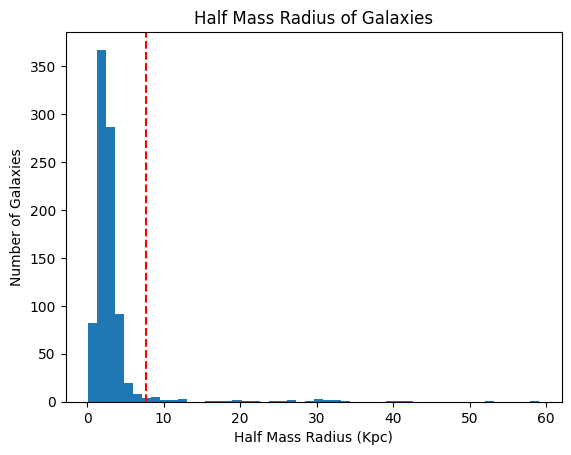

In [5]:
dataframe = pd.read_csv('galaxies_dataframe.csv')

gals = dataframe['Gal_number'].values

r_half = []
pot_weird_gals = []

for gal in gals:
    r_half.append(dataframe[dataframe['Gal_number'] == int(gal)]['r_half'].values[0])
    if r_half[-1] > 6:
        pot_weird_gals.append(int(gal))



print(pot_weird_gals)
    


print(r_half)
plt.hist(r_half, bins = 50)
plt.axvline(x = 7.7, color = 'r', linestyle = '--', label = 'Galaxy Radius')

plt.xlabel('Half Mass Radius (Kpc)')
plt.ylabel('Number of Galaxies')
plt.title('Half Mass Radius of Galaxies')
plt.show()

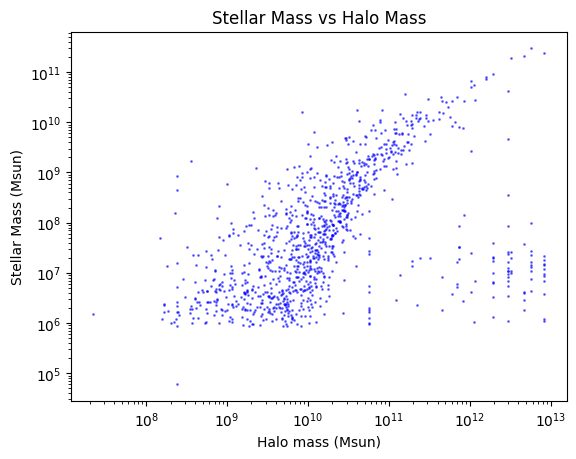

In [6]:
halo_virial_radii = df['Halo Radius (Kpc)']

stellar_masses = df['Galaxy Mass (Msun)']

halo_masses = df['Halo Mass (Msun)']

stellar_radii = df['Galaxy Radius (Kpc)']


plt.scatter(halo_masses, stellar_masses, s=1, alpha=0.5, c='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Halo mass (Msun)')
plt.ylabel('Stellar Mass (Msun)')
plt.title('Stellar Mass vs Halo Mass')

plt.show()



[]

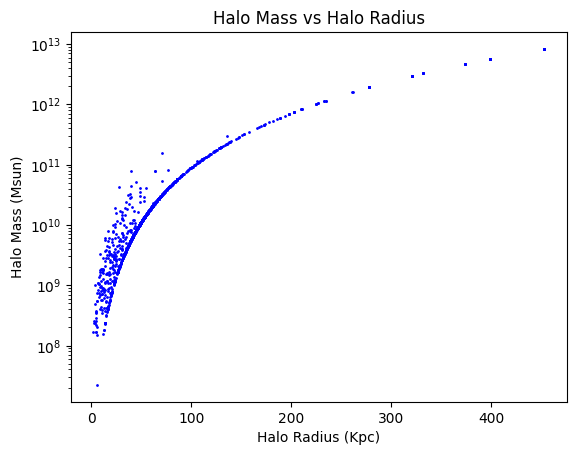

In [7]:
plt.scatter(halo_virial_radii, halo_masses, s=1, color='blue')
plt.ylabel('Halo Mass (Msun)')
plt.yscale('log')
plt.xlabel('Halo Radius (Kpc)')
plt.title('Halo Mass vs Halo Radius')

plt.plot()
